In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

clients = pd.read_csv('/content/clients.csv')
properties = pd.read_csv('/content/properties.csv')

print("Clients shape:", clients.shape)
print("Properties shape:", properties.shape)

display(clients.head())
display(properties.head())

Clients shape: (2000, 12)
Properties shape: (10000, 9)


,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel
0,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,Yes,Website
1,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,No,Website
2,C0003,Individual,Kale,Gay,04-07-1959,M,USA,California,Home,4,Yes,Agency
3,C0004,Individual,Russell,Gross,11/25/1959,M,USA,California,Home,5,No,Website
4,C0005,Company,Marleez,Co,2/28/1976,M,USA,California,Investment,5,No,Website


,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref
0,1012,1,01-01-2024,Apartment,12,1160.36,"$300,385.62",Sold,C0027
1,1015,1,01-01-2024,Apartment,15,782.25,"$208,930.81",Sold,C0097
2,1021,1,01-01-2024,Apartment,21,756.21,"$218,585.92",Sold,C0113
3,1030,1,01-01-2024,Apartment,30,743.09,"$246,172.68",Sold,C0141
4,2016,2,01-01-2024,Apartment,16,701.66,"$212,265.67",Sold,C0146


In [4]:
properties['sale_price'] = (
    properties['sale_price']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

print(properties['sale_price'].dtype)

float64


In [5]:
sold_properties = properties[
    properties['listing_status'] == 'Sold'
].copy()

print("Sold properties:", len(sold_properties))

Sold properties: 7305


In [6]:
property_summary = sold_properties.groupby('client_ref').agg(
    properties_purchased=('listing_id', 'count'),
    total_spend=('sale_price', 'sum'),
    avg_property_price=('sale_price', 'mean'),
    total_area_sqft=('floor_area_sqft', 'sum'),
    avg_area_sqft=('floor_area_sqft', 'mean'),
    apartment_purchases=(
        'unit_category',
        lambda x: (x == 'Apartment').sum()
    ),
    office_purchases=(
        'unit_category',
        lambda x: (x == 'Office').sum()
    )
).reset_index()

display(property_summary.head())

,client_ref,properties_purchased,total_spend,avg_property_price,total_area_sqft,avg_area_sqft,apartment_purchases,office_purchases
0,C0001,4,1246764.72,311691.180000,3935.54,983.885000,4,0
1,C0002,5,1841095.93,368219.186000,5939.71,1187.942000,5,0
2,C0003,5,1661457.59,332291.518000,5290.55,1058.110000,5,0
3,C0004,6,1608263.51,268043.918333,5622.62,937.103333,6,0
4,C0005,13,3653385.38,281029.644615,12054.85,927.296154,13,0


In [7]:
final_df = clients.merge(
    property_summary,
    left_on='client_id',
    right_on='client_ref',
    how='left'
)

final_df.drop(columns=['client_ref'], inplace=True)

display(final_df.head())

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel,properties_purchased,total_spend,avg_property_price,total_area_sqft,avg_area_sqft,apartment_purchases,office_purchases
0,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,Yes,Website,4,1246764.72,311691.180000,3935.54,983.885000,4,0
1,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,No,Website,5,1841095.93,368219.186000,5939.71,1187.942000,5,0
2,C0003,Individual,Kale,Gay,04-07-1959,M,USA,California,Home,4,Yes,Agency,5,1661457.59,332291.518000,5290.55,1058.110000,5,0
3,C0004,Individual,Russell,Gross,11/25/1959,M,USA,California,Home,5,No,Website,6,1608263.51,268043.918333,5622.62,937.103333,6,0
4,C0005,Company,Marleez,Co,2/28/1976,M,USA,California,Investment,5,No,Website,13,3653385.38,281029.644615,12054.85,927.296154,13,0


In [8]:
print("Final dataset shape:", final_df.shape)

Final dataset shape: (2000, 19)


In [9]:
final_df.to_csv(
    '/content/real_estate_buyer_master.csv',
    index=False
)

In [10]:
print("Column names:")
for i, col in enumerate(final_df.columns, 1):
    print(i, "→", col)

Column names:
1 → client_id
2 → client_type
3 → first_name
4 → last_name
5 → date_of_birth
6 → gender
7 → country
8 → region
9 → acquisition_purpose
10 → satisfaction_score
11 → loan_applied
12 → referral_channel
13 → properties_purchased
14 → total_spend
15 → avg_property_price
16 → total_area_sqft
17 → avg_area_sqft
18 → apartment_purchases
19 → office_purchases


In [11]:
print("Missing values in each column:")
print(final_df.isnull().sum())

Missing values in each column:
client_id               0
client_type             0
first_name              0
last_name               0
date_of_birth           0
gender                  0
country                 0
region                  0
acquisition_purpose     0
satisfaction_score      0
loan_applied            0
referral_channel        0
properties_purchased    0
total_spend             0
avg_property_price      0
total_area_sqft         0
avg_area_sqft           0
apartment_purchases     0
office_purchases        0
dtype: int64


In [12]:
print("Total missing values:", final_df.isnull().sum().sum())

Total missing values: 0


In [13]:
print("Duplicate rows:", final_df.duplicated().sum())
print("Duplicate client IDs:", final_df['client_id'].duplicated().sum())

Duplicate rows: 0
Duplicate client IDs: 0


In [14]:
final_df['date_of_birth'] = pd.to_datetime(
    final_df['date_of_birth'],
    format='mixed',
    errors='coerce'
)

print(final_df['date_of_birth'].head())

0   1968-05-11
1   1962-11-26
2   1959-04-07
3   1959-11-25
4   1976-02-28
Name: date_of_birth, dtype: datetime64[ns]


In [15]:
today = pd.Timestamp.today()

final_df['age'] = (
    (today - final_df['date_of_birth']).dt.days / 365.25
).round(0)

display(final_df[['date_of_birth', 'age']].head())

,date_of_birth,age
0,1968-05-11,58.0
1,1962-11-26,64.0
2,1959-04-07,67.0
3,1959-11-25,67.0
4,1976-02-28,50.0


In [16]:
print(final_df['age'].describe())

count    2000.000000
mean       56.196500
std        17.347373
min        26.000000
25%        41.000000
50%        57.000000
75%        71.000000
max        95.000000
Name: age, dtype: float64


In [17]:
print("Age below 18:", (final_df['age'] < 18).sum())
print("Age above 100:", (final_df['age'] > 100).sum())

Age below 18: 0
Age above 100: 0


In [18]:
final_df.describe().T

,count,mean,min,25%,50%,75%,max,std
date_of_birth,2000,1970-05-26 02:22:33.600000,1931-02-13 00:00:00,1955-12-21 12:00:00,1969-10-25 00:00:00,1985-02-19 18:00:00,2000-12-19 00:00:00,NaN
satisfaction_score,2000.0,3.029,1.0,2.0,3.0,4.0,5.0,1.413562
properties_purchased,2000.0,3.6525,3.0,3.0,4.0,4.0,13.0,0.8397
total_spend,2000.0,1260375.48042,463611.95,1025238.005,1220893.165,1441973.8825,3653385.38,347830.664827
avg_property_price,2000.0,347089.955869,154537.316667,295807.677708,341523.383333,390843.316875,563423.5,69721.821814
total_area_sqft,2000.0,4168.04248,1692.03,3387.53,4061.095,4740.3275,12054.85,1130.165735
avg_area_sqft,2000.0,1147.479668,564.01,984.9525,1129.176667,1296.5625,1800.45,219.922587
apartment_purchases,2000.0,3.1125,0.0,3.0,3.0,4.0,13.0,0.99867
office_purchases,2000.0,0.54,0.0,0.0,0.0,1.0,4.0,0.672775
age,2000.0,56.1965,26.0,41.0,57.0,71.0,95.0,17.347373


In [19]:
categorical_columns = [
    'client_type',
    'gender',
    'country',
    'region',
    'acquisition_purpose',
    'loan_applied',
    'referral_channel'
]

for col in categorical_columns:
    print("\n" + "="*50)
    print(col)
    print(final_df[col].value_counts(dropna=False))


client_type
client_type
Individual    1897
Company        103
Name: count, dtype: int64

gender
gender
M    1012
F     988
Name: count, dtype: int64

country
country
USA          1538
UK             95
Canada         85
Germany        56
France         53
Belgium        43
Mexico         40
Australia      39
Russia         36
Denmark        15
Name: count, dtype: int64

region
region
California                633
Nevada                    143
Colorado                  118
Arizona                   108
Oregon                     96
Utah                       87
Washington                 73
Virginia                   65
Texas                      56
Florida                    50
New York                   49
Georgia                    34
England                    29
Alberta                    27
Scotland                   25
Ohio                       24
Northern Ireland           24
British Columbia           20
Wales                      17
Brittany                   16
Flanders    

# 📊 3. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand buyer demographics,
investment behavior, financing patterns, customer satisfaction,
property purchasing behavior, and geographic distribution.

The analysis will identify important patterns and relationships
that will be used later for machine learning based buyer segmentation.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("EDA libraries loaded successfully!")

EDA libraries loaded successfully!


In [21]:
print("========== REAL ESTATE BUYER DATASET ==========")

print("Total Buyers:", len(final_df))
print("Total Features:", len(final_df.columns))

print("\n========== BUYER TYPES ==========")
print(final_df['client_type'].value_counts())

print("\n========== ACQUISITION PURPOSE ==========")
print(final_df['acquisition_purpose'].value_counts())

print("\n========== LOAN APPLICATION ==========")
print(final_df['loan_applied'].value_counts())

print("\n========== REFERRAL CHANNEL ==========")
print(final_df['referral_channel'].value_counts())

========== REAL ESTATE BUYER DATASET ==========
Total Buyers: 2000
Total Features: 20

========== BUYER TYPES ==========
client_type
Individual    1897
Company        103
Name: count, dtype: int64

========== ACQUISITION PURPOSE ==========
acquisition_purpose
Home          1385
Investment     615
Name: count, dtype: int64

========== LOAN APPLICATION ==========
loan_applied
No     1264
Yes     736
Name: count, dtype: int64

========== REFERRAL CHANNEL ==========
referral_channel
Website    1103
Agency      705
Client      192
Name: count, dtype: int64


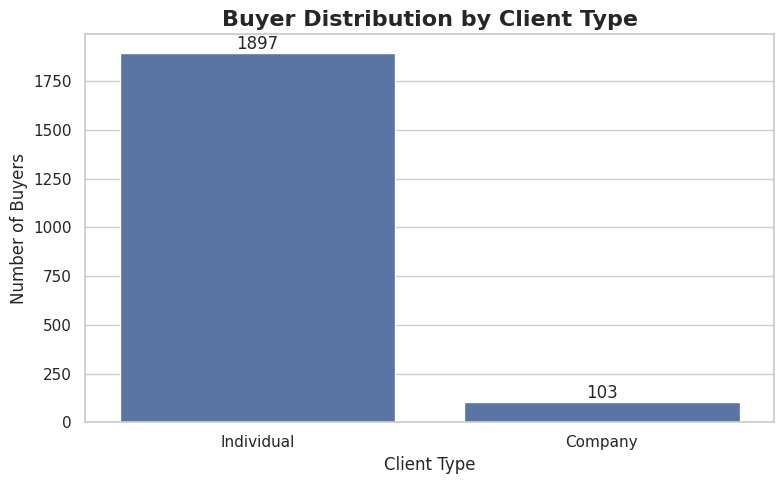

In [22]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=final_df,
    x='client_type'
)

plt.title(
    'Buyer Distribution by Client Type',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Client Type', fontsize=12)
plt.ylabel('Number of Buyers', fontsize=12)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

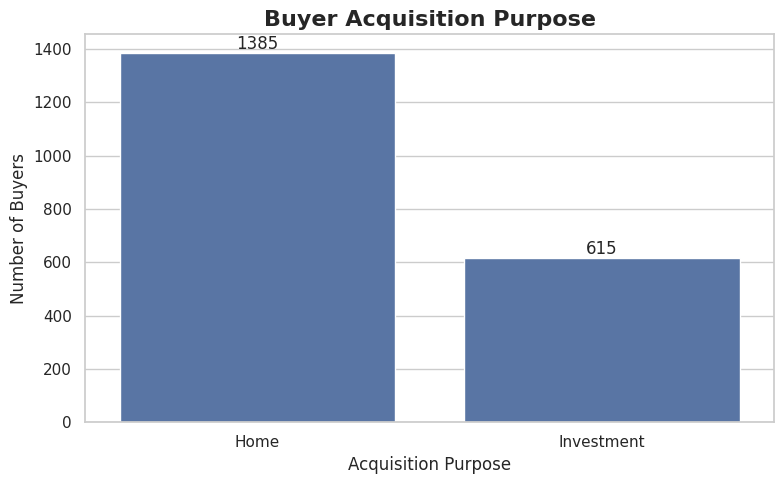

In [23]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=final_df,
    x='acquisition_purpose'
)

plt.title(
    'Buyer Acquisition Purpose',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Acquisition Purpose', fontsize=12)
plt.ylabel('Number of Buyers', fontsize=12)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

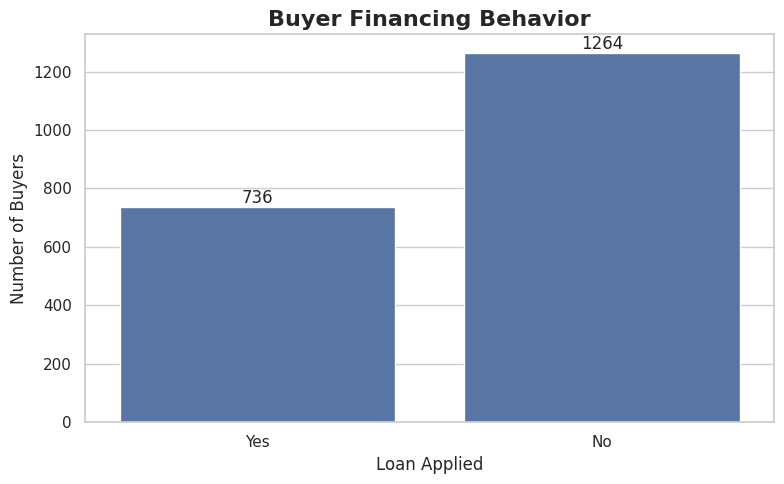

In [24]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=final_df,
    x='loan_applied'
)

plt.title(
    'Buyer Financing Behavior',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Loan Applied', fontsize=12)
plt.ylabel('Number of Buyers', fontsize=12)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

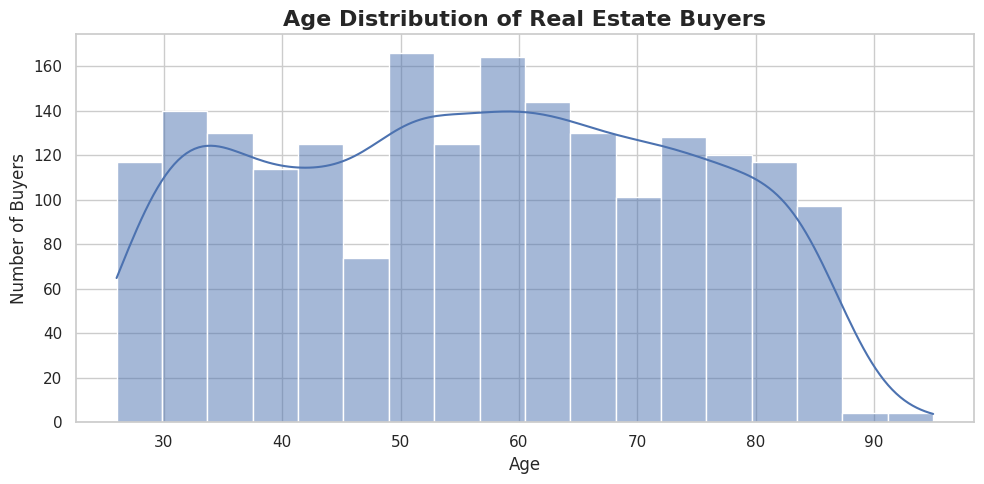

In [25]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=final_df,
    x='age',
    bins=18,
    kde=True
)

plt.title(
    'Age Distribution of Real Estate Buyers',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Age', fontsize=12)
plt.ylabel('Number of Buyers', fontsize=12)

plt.tight_layout()
plt.show()

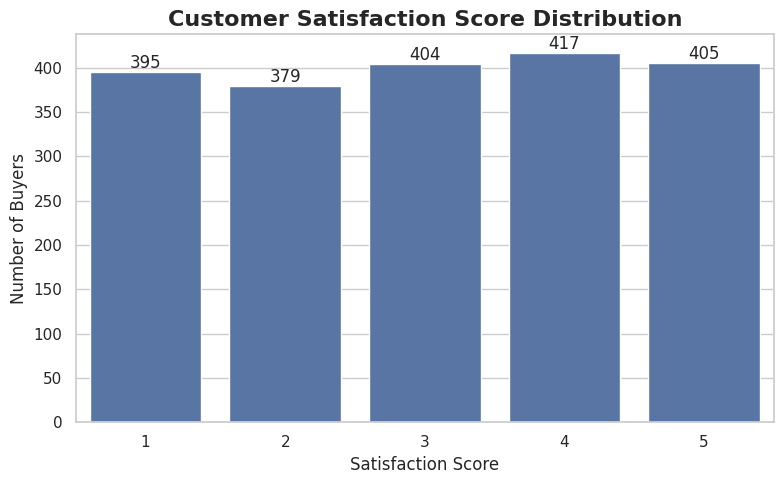

In [26]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=final_df,
    x='satisfaction_score'
)

plt.title(
    'Customer Satisfaction Score Distribution',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Satisfaction Score', fontsize=12)
plt.ylabel('Number of Buyers', fontsize=12)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

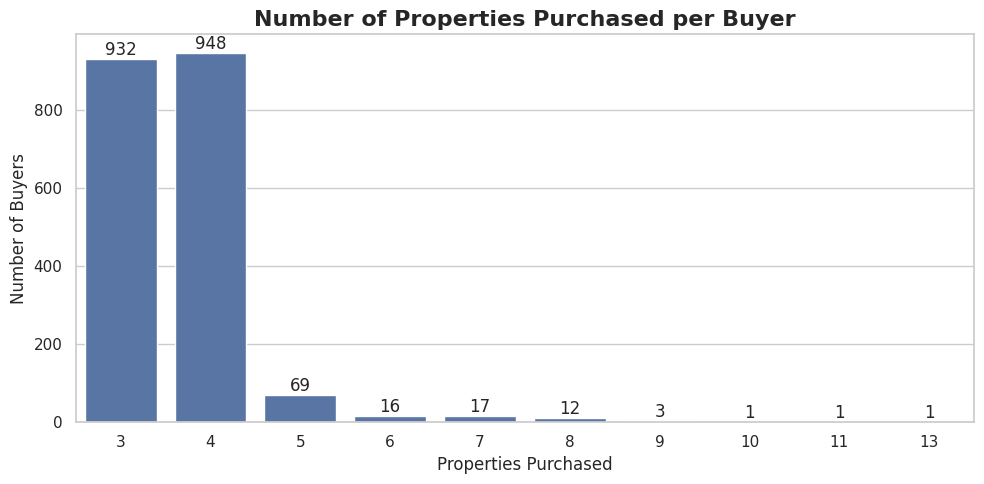

In [27]:
plt.figure(figsize=(10, 5))

ax = sns.countplot(
    data=final_df,
    x='properties_purchased'
)

plt.title(
    'Number of Properties Purchased per Buyer',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Properties Purchased', fontsize=12)
plt.ylabel('Number of Buyers', fontsize=12)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

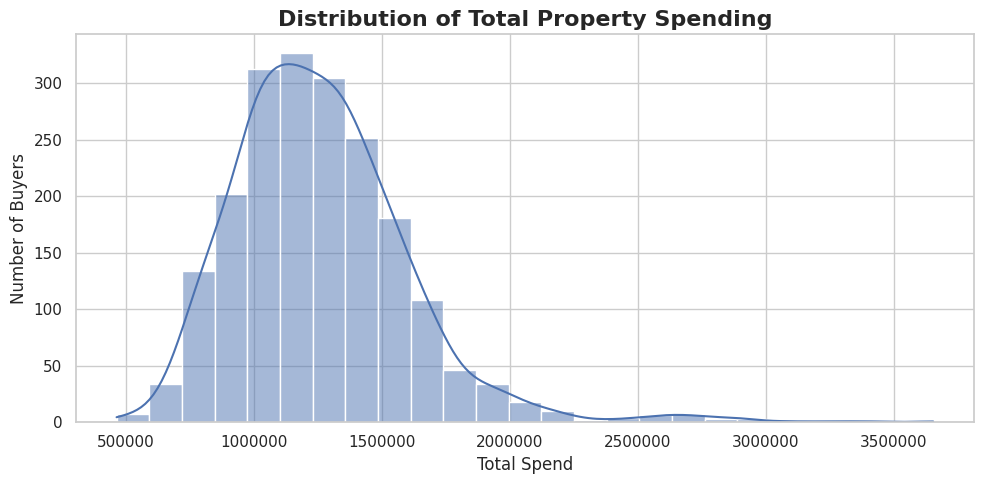

In [28]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=final_df,
    x='total_spend',
    bins=25,
    kde=True
)

plt.title(
    'Distribution of Total Property Spending',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Total Spend', fontsize=12)
plt.ylabel('Number of Buyers', fontsize=12)

plt.ticklabel_format(
    style='plain',
    axis='x'
)

plt.tight_layout()
plt.show()

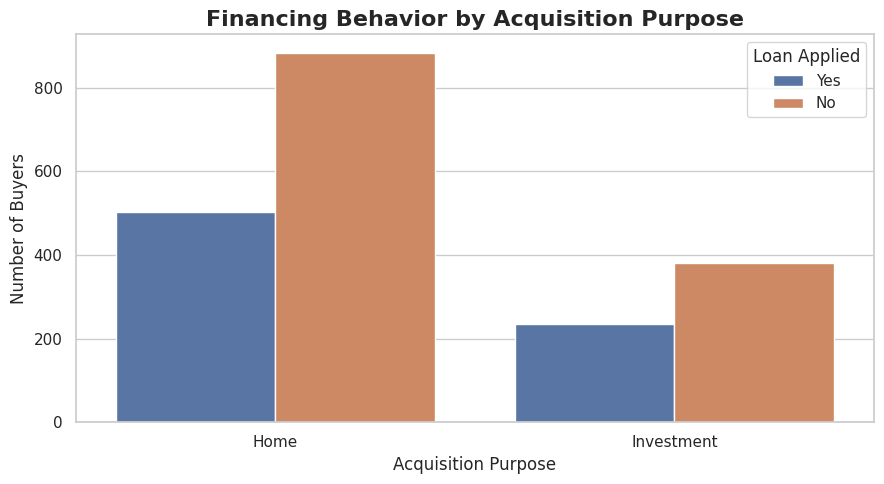

In [29]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=final_df,
    x='acquisition_purpose',
    hue='loan_applied'
)

plt.title(
    'Financing Behavior by Acquisition Purpose',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Acquisition Purpose', fontsize=12)
plt.ylabel('Number of Buyers', fontsize=12)

plt.legend(title='Loan Applied')

plt.tight_layout()
plt.show()

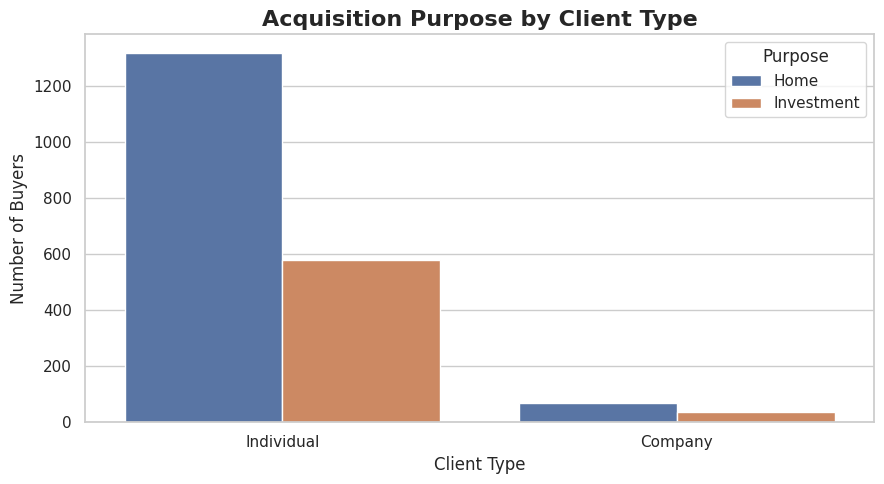

In [30]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=final_df,
    x='client_type',
    hue='acquisition_purpose'
)

plt.title(
    'Acquisition Purpose by Client Type',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Client Type', fontsize=12)
plt.ylabel('Number of Buyers', fontsize=12)

plt.legend(title='Purpose')

plt.tight_layout()
plt.show()

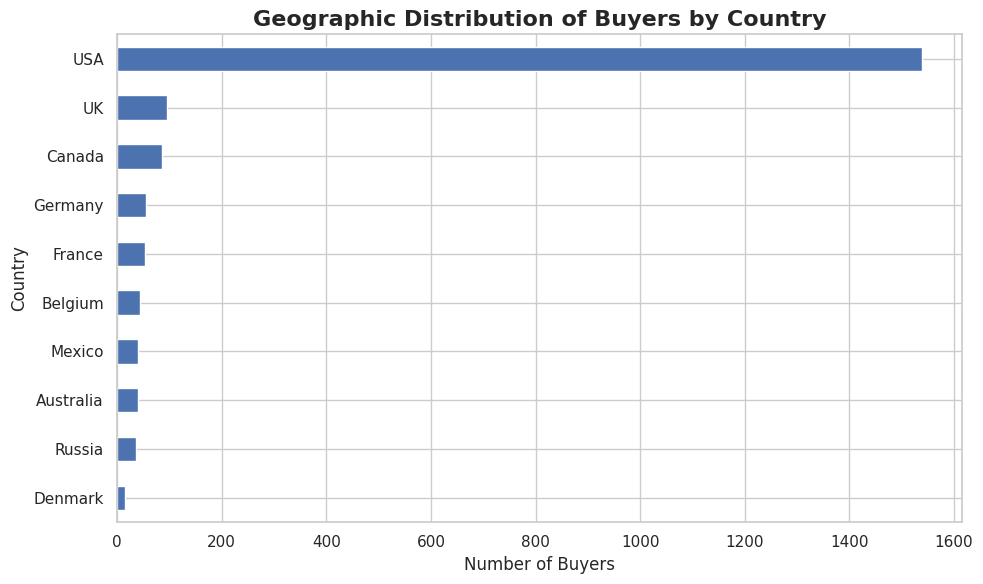

In [31]:
country_counts = (
    final_df['country']
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))

country_counts.plot(kind='barh')

plt.title(
    'Geographic Distribution of Buyers by Country',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Number of Buyers', fontsize=12)
plt.ylabel('Country', fontsize=12)

plt.tight_layout()
plt.show()

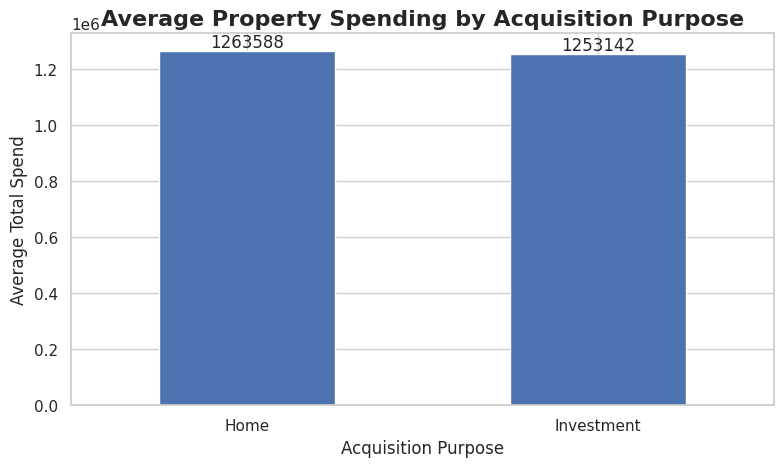

In [32]:
avg_spending = (
    final_df
    .groupby('acquisition_purpose')['total_spend']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

ax = avg_spending.plot(kind='bar')

plt.title(
    'Average Property Spending by Acquisition Purpose',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Acquisition Purpose', fontsize=12)
plt.ylabel('Average Total Spend', fontsize=12)

plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.0f'
    )

plt.tight_layout()
plt.show()

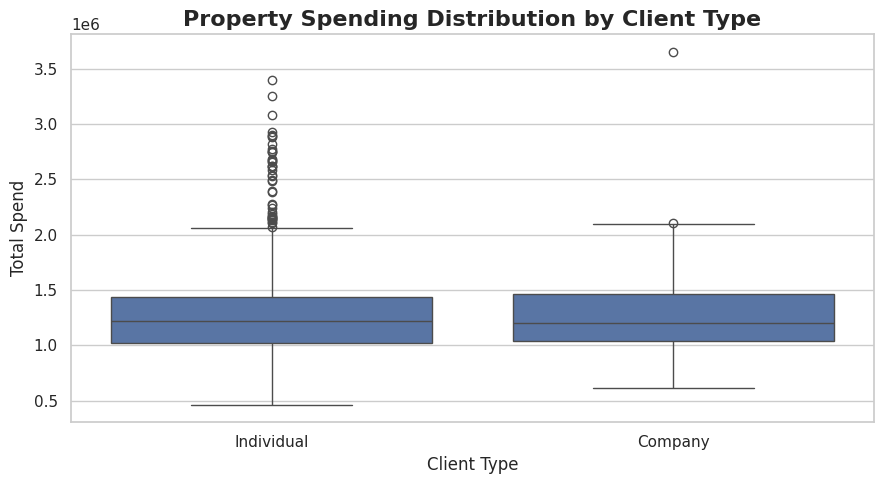

In [33]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=final_df,
    x='client_type',
    y='total_spend'
)

plt.title(
    'Property Spending Distribution by Client Type',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Client Type', fontsize=12)
plt.ylabel('Total Spend', fontsize=12)

plt.tight_layout()
plt.show()

## 🔗 Numerical Feature Correlation Analysis

Correlation analysis is used to identify relationships among buyer age,
satisfaction, property purchases, spending, property prices, and
property area.

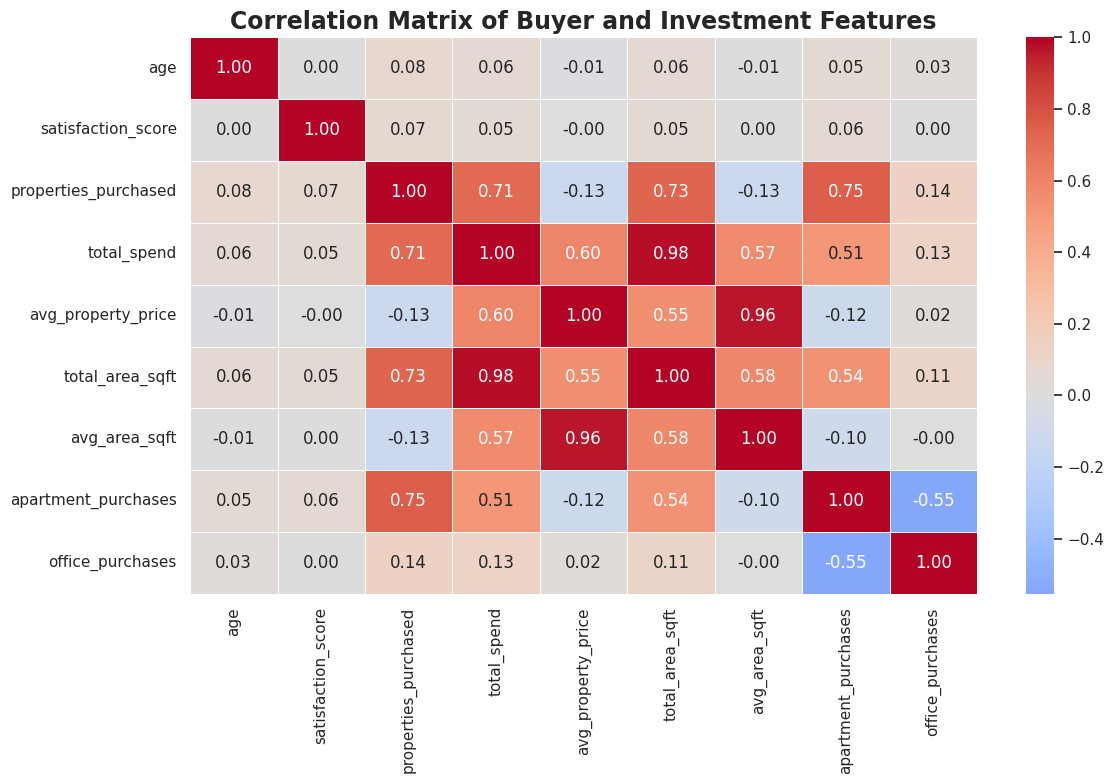

In [34]:
numeric_features = [
    'age',
    'satisfaction_score',
    'properties_purchased',
    'total_spend',
    'avg_property_price',
    'total_area_sqft',
    'avg_area_sqft',
    'apartment_purchases',
    'office_purchases'
]

correlation_matrix = final_df[numeric_features].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title(
    'Correlation Matrix of Buyer and Investment Features',
    fontsize=17,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

# 🧠 4. Feature Engineering & Machine Learning Preparation

The exploratory analysis identified several strongly correlated variables.
To avoid excessive weighting of redundant information during clustering,
the machine-learning feature set is carefully selected.

Personal identifiers such as client ID, first name, last name, and date
of birth are excluded from the clustering model.

Age is retained as the demographic indicator.

In [35]:
# Numerical features selected for buyer segmentation

numeric_features = [
    'age',
    'satisfaction_score',
    'properties_purchased',
    'total_spend',
    'avg_property_price',
    'apartment_purchases',
    'office_purchases'
]

print("Numerical features:")
for feature in numeric_features:
    print("✓", feature)

Numerical features:
✓ age
✓ satisfaction_score
✓ properties_purchased
✓ total_spend
✓ avg_property_price
✓ apartment_purchases
✓ office_purchases


In [36]:
categorical_features = [
    'client_type',
    'gender',
    'country',
    'region',
    'acquisition_purpose',
    'loan_applied',
    'referral_channel'
]

print("Categorical features:")
for feature in categorical_features:
    print("✓", feature)

Categorical features:
✓ client_type
✓ gender
✓ country
✓ region
✓ acquisition_purpose
✓ loan_applied
✓ referral_channel


In [37]:
ml_df = final_df[
    numeric_features + categorical_features
].copy()

print("Machine Learning Dataset Shape:")
print(ml_df.shape)

display(ml_df.head())

Machine Learning Dataset Shape:
(2000, 14)


,age,satisfaction_score,properties_purchased,total_spend,avg_property_price,apartment_purchases,office_purchases,client_type,gender,country,region,acquisition_purpose,loan_applied,referral_channel
0,58.0,4,4,1246764.72,311691.180000,4,0,Individual,F,USA,California,Home,Yes,Website
1,64.0,1,5,1841095.93,368219.186000,5,0,Individual,M,USA,California,Home,No,Website
2,67.0,4,5,1661457.59,332291.518000,5,0,Individual,M,USA,California,Home,Yes,Agency
3,67.0,5,6,1608263.51,268043.918333,6,0,Individual,M,USA,California,Home,No,Website
4,50.0,5,13,3653385.38,281029.644615,13,0,Company,M,USA,California,Investment,No,Website


# ⚙️ 5. Data Preprocessing

Categorical variables are converted into numerical representations using
One-Hot Encoding.

Numerical variables are standardized using StandardScaler so that
features with larger numerical ranges do not dominate the clustering
algorithm.

In [38]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

print("Preprocessing libraries loaded successfully.")

Preprocessing libraries loaded successfully.


In [39]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'numeric',
            StandardScaler(),
            numeric_features
        ),
        (
            'categorical',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

X = preprocessor.fit_transform(ml_df)

print("Processed dataset shape:", X.shape)

Processed dataset shape: (2000, 85)


In [40]:
print("Original ML features:", len(numeric_features) + len(categorical_features))
print("Processed ML features:", X.shape[1])

Original ML features: 14
Processed ML features: 85


# 🤖 6. K-Means Buyer Segmentation

K-Means clustering is used to group buyers with similar demographic,
financial, purchasing, financing, and acquisition characteristics.

The optimal number of clusters will be determined using:

1. Elbow Method
2. Silhouette Score

The number of clusters will not be assumed in advance.

In [41]:
from sklearn.cluster import KMeans

inertia = []

K_range = range(2, 11)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    kmeans.fit(X)

    inertia.append(kmeans.inertia_)

print("Elbow calculation completed.")

Elbow calculation completed.


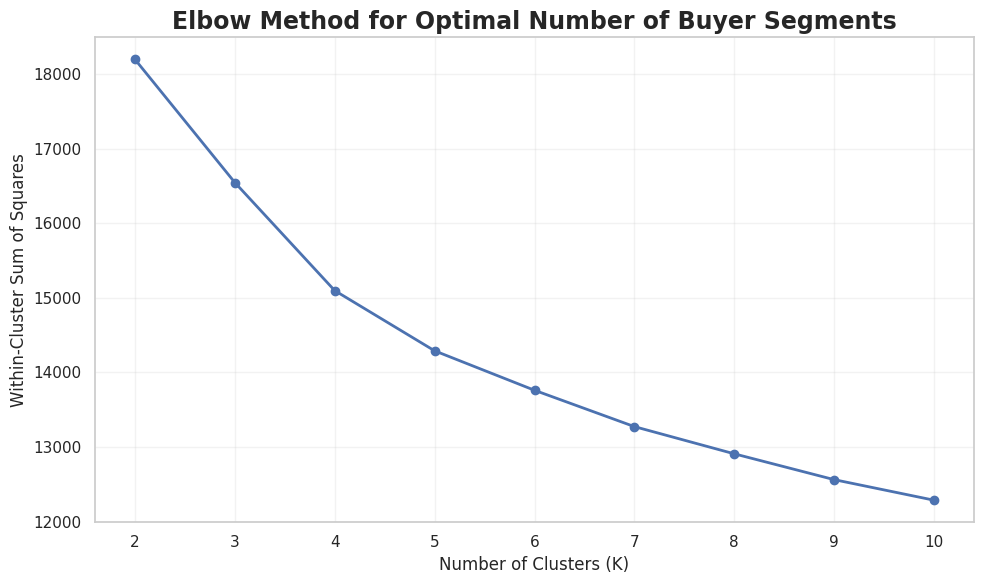

In [42]:
plt.figure(figsize=(10, 6))

plt.plot(
    K_range,
    inertia,
    marker='o',
    linewidth=2
)

plt.title(
    'Elbow Method for Optimal Number of Buyer Segments',
    fontsize=17,
    fontweight='bold'
)

plt.xlabel(
    'Number of Clusters (K)',
    fontsize=12
)

plt.ylabel(
    'Within-Cluster Sum of Squares',
    fontsize=12
)

plt.xticks(K_range)

plt.grid(
    alpha=0.25
)

plt.tight_layout()
plt.show()

In [43]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X)

    score = silhouette_score(X, labels)

    silhouette_scores.append(score)

print("Silhouette analysis completed.")

Silhouette analysis completed.


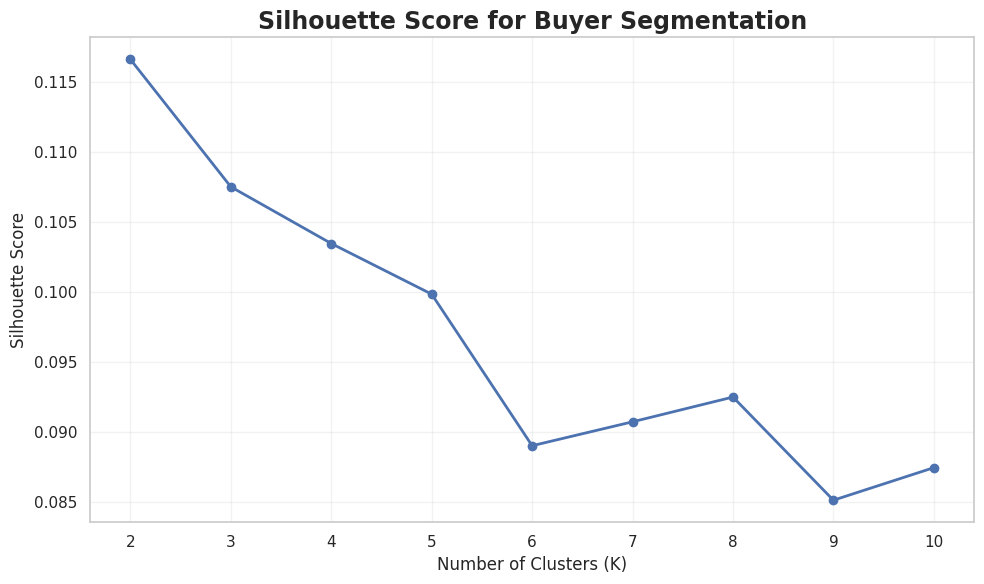

In [44]:
plt.figure(figsize=(10, 6))

plt.plot(
    K_range,
    silhouette_scores,
    marker='o',
    linewidth=2
)

plt.title(
    'Silhouette Score for Buyer Segmentation',
    fontsize=17,
    fontweight='bold'
)

plt.xlabel(
    'Number of Clusters (K)',
    fontsize=12
)

plt.ylabel(
    'Silhouette Score',
    fontsize=12
)

plt.xticks(K_range)

plt.grid(
    alpha=0.25
)

plt.tight_layout()
plt.show()

In [45]:
# Find the K with the highest Silhouette Score

best_k = K_range[
    np.argmax(silhouette_scores)
]

best_score = max(silhouette_scores)

print("Best K based on Silhouette Score:", best_k)
print("Best Silhouette Score:", round(best_score, 4))

Best K based on Silhouette Score: 2
Best Silhouette Score: 0.1166


# 🤖 7. Final K-Means Buyer Segmentation

Based on the clustering evaluation, the selected number of clusters
is used to train the final K-Means model.

Each buyer is assigned to a segment according to similarity across
demographic, purchasing, financial, financing, and acquisition
characteristics.

In [46]:
# Train final K-Means model

OPTIMAL_K = best_k

final_kmeans = KMeans(
    n_clusters=OPTIMAL_K,
    random_state=42,
    n_init=20
)

final_df['cluster'] = final_kmeans.fit_predict(X)

print("Final K:", OPTIMAL_K)
print("\nBuyer count by cluster:")
print(
    final_df['cluster']
    .value_counts()
    .sort_index()
)

Final K: 2

Buyer count by cluster:
cluster
0    1297
1     703
Name: count, dtype: int64


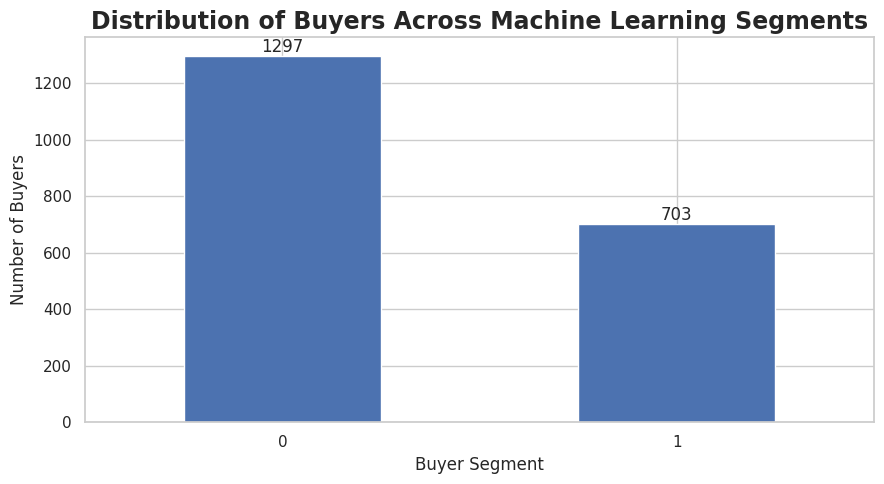

In [47]:
cluster_counts = (
    final_df['cluster']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(9, 5))

ax = cluster_counts.plot(
    kind='bar'
)

plt.title(
    'Distribution of Buyers Across Machine Learning Segments',
    fontsize=17,
    fontweight='bold'
)

plt.xlabel('Buyer Segment')
plt.ylabel('Number of Buyers')

plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [48]:
cluster_summary = pd.DataFrame({
    'Buyer Count': final_df['cluster'].value_counts().sort_index()
})

cluster_summary['Percentage'] = (
    cluster_summary['Buyer Count']
    / len(final_df) * 100
).round(2)

display(cluster_summary)

,Buyer Count,Percentage
cluster,,
0,1297,64.85
1,703,35.15


# 📍 8. PCA Visualization of Buyer Segments

Principal Component Analysis (PCA) is used to reduce the high-dimensional
machine-learning feature space to two dimensions for visualization.

The visualization allows the identified buyer segments to be observed
in a two-dimensional space.

In [49]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

pca_df['cluster'] = final_df['cluster'].values

print(
    "Variance explained by PC1:",
    round(pca.explained_variance_ratio_[0] * 100, 2),
    "%"
)

print(
    "Variance explained by PC2:",
    round(pca.explained_variance_ratio_[1] * 100, 2),
    "%"
)

Variance explained by PC1: 23.06 %
Variance explained by PC2: 14.59 %


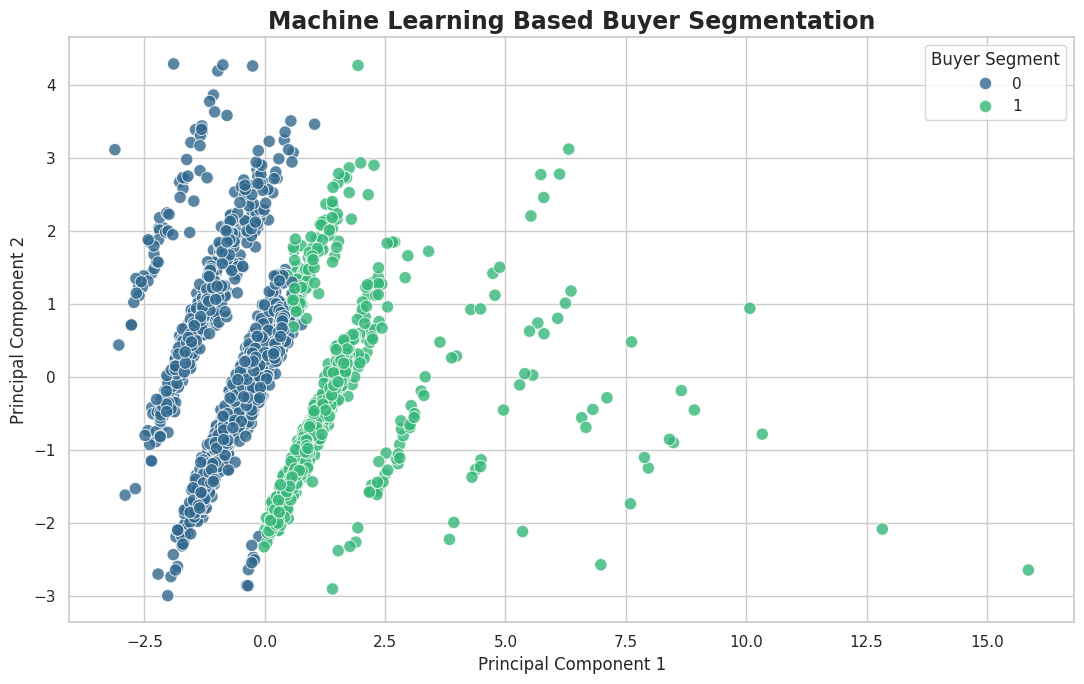

In [50]:
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='viridis',
    s=80,
    alpha=0.8
)

plt.title(
    'Machine Learning Based Buyer Segmentation',
    fontsize=17,
    fontweight='bold'
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.legend(
    title='Buyer Segment'
)

plt.tight_layout()
plt.show()

# 👥 9. Buyer Segment Profiling

Each machine-learning cluster is analyzed using demographic,
financial, purchasing, satisfaction, and property-related characteristics.

This allows the numerical clusters to be converted into meaningful
business-oriented buyer segments.

In [51]:
cluster_profile = final_df.groupby('cluster').agg(
    buyer_count=('client_id', 'count'),
    average_age=('age', 'mean'),
    average_satisfaction=('satisfaction_score', 'mean'),
    average_properties=('properties_purchased', 'mean'),
    average_total_spend=('total_spend', 'mean'),
    average_property_price=('avg_property_price', 'mean'),
    apartment_purchases=('apartment_purchases', 'mean'),
    office_purchases=('office_purchases', 'mean')
).round(2)

display(cluster_profile)

,buyer_count,average_age,average_satisfaction,average_properties,average_total_spend,average_property_price,apartment_purchases,office_purchases
cluster,,,,,,,,
0,1297,55.56,2.96,3.29,1121831.07,343714.91,2.60,0.69
1,703,57.38,3.16,4.32,1515983.03,353316.76,4.06,0.26


In [52]:
purpose_profile = pd.crosstab(
    final_df['cluster'],
    final_df['acquisition_purpose'],
    normalize='index'
) * 100

purpose_profile = purpose_profile.round(2)

display(purpose_profile)

acquisition_purpose,Home,Investment
cluster,,
0,67.85,32.15
1,71.83,28.17


In [53]:
loan_profile = pd.crosstab(
    final_df['cluster'],
    final_df['loan_applied'],
    normalize='index'
) * 100

loan_profile = loan_profile.round(2)

display(loan_profile)

loan_applied,No,Yes
cluster,,
0,62.14,37.86
1,65.15,34.85


In [54]:
client_type_profile = pd.crosstab(
    final_df['cluster'],
    final_df['client_type'],
    normalize='index'
) * 100

client_type_profile = client_type_profile.round(2)

display(client_type_profile)

client_type,Company,Individual
cluster,,
0,4.86,95.14
1,5.69,94.31


In [55]:
country_profile = pd.crosstab(
    final_df['cluster'],
    final_df['country'],
    normalize='index'
) * 100

country_profile = country_profile.round(2)

display(country_profile)

country,Australia,Belgium,Canada,Denmark,France,Germany,Mexico,Russia,UK,USA
cluster,,,,,,,,,,
0,2.16,2.16,4.70,0.62,2.85,3.24,2.16,1.70,4.55,75.87
1,1.56,2.13,3.41,1.00,2.28,1.99,1.71,1.99,5.12,78.81


In [56]:
for cluster in sorted(final_df['cluster'].unique()):

    cluster_data = final_df[
        final_df['cluster'] == cluster
    ]

    print(f"\nCluster {cluster} — Top Countries")

    print(
        cluster_data['country']
        .value_counts()
        .head(3)
    )


Cluster 0 — Top Countries
country
USA       984
Canada     61
UK         59
Name: count, dtype: int64

Cluster 1 — Top Countries
country
USA       554
UK         36
Canada     24
Name: count, dtype: int64


In [57]:
referral_profile = pd.crosstab(
    final_df['cluster'],
    final_df['referral_channel'],
    normalize='index'
) * 100

referral_profile = referral_profile.round(2)

display(referral_profile)

referral_channel,Agency,Client,Website
cluster,,,
0,36.85,9.71,53.43
1,32.29,9.39,58.32


In [58]:
segment_comparison = final_df.groupby('cluster').agg(
    Buyers=('client_id', 'count'),
    Avg_Age=('age', 'mean'),
    Avg_Satisfaction=('satisfaction_score', 'mean'),
    Avg_Properties=('properties_purchased', 'mean'),
    Avg_Spending=('total_spend', 'mean'),
    Avg_Property_Price=('avg_property_price', 'mean'),
    Avg_Apartments=('apartment_purchases', 'mean'),
    Avg_Offices=('office_purchases', 'mean')
).round(2)

display(segment_comparison)

,Buyers,Avg_Age,Avg_Satisfaction,Avg_Properties,Avg_Spending,Avg_Property_Price,Avg_Apartments,Avg_Offices
cluster,,,,,,,,
0,1297,55.56,2.96,3.29,1121831.07,343714.91,2.60,0.69
1,703,57.38,3.16,4.32,1515983.03,353316.76,4.06,0.26


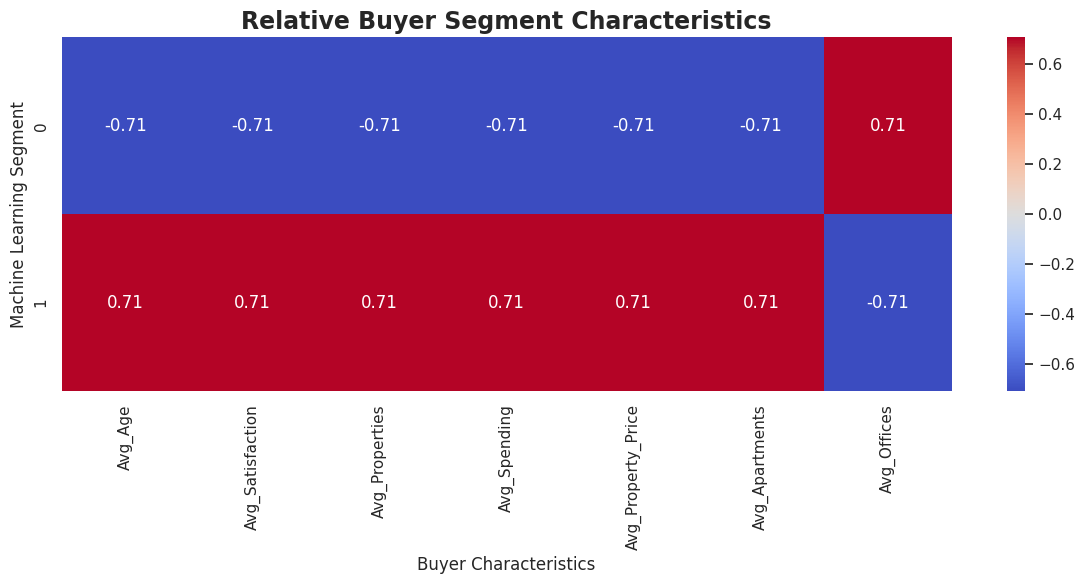

In [59]:
profile_for_heatmap = segment_comparison.copy()

# Remove buyer count because it is on a different scale
profile_for_heatmap = profile_for_heatmap.drop(
    columns=['Buyers']
)

# Standardize each metric across clusters
profile_scaled = (
    profile_for_heatmap -
    profile_for_heatmap.mean()
) / profile_for_heatmap.std()

plt.figure(figsize=(12, 6))

sns.heatmap(
    profile_scaled,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title(
    'Relative Buyer Segment Characteristics',
    fontsize=17,
    fontweight='bold'
)

plt.xlabel('Buyer Characteristics')
plt.ylabel('Machine Learning Segment')

plt.tight_layout()
plt.show()

In [60]:
for cluster in segment_comparison.index:

    print("\n" + "="*60)
    print(f"CLUSTER {cluster}")
    print("="*60)

    cluster_values = segment_comparison.loc[cluster]

    print(
        cluster_values
        .sort_values(ascending=False)
        .to_string()
    )


CLUSTER 0
Avg_Spending          1121831.07
Avg_Property_Price     343714.91
Buyers                   1297.00
Avg_Age                    55.56
Avg_Properties              3.29
Avg_Satisfaction            2.96
Avg_Apartments              2.60
Avg_Offices                 0.69

CLUSTER 1
Avg_Spending          1515983.03
Avg_Property_Price     353316.76
Buyers                    703.00
Avg_Age                    57.38
Avg_Properties              4.32
Avg_Apartments              4.06
Avg_Satisfaction            3.16
Avg_Offices                 0.26


# 🌳 10. Hierarchical Clustering

Hierarchical clustering is used as a second clustering approach to
validate the buyer segments identified using K-Means.

Agglomerative hierarchical clustering progressively combines similar
buyers into groups and helps reveal the hierarchical structure of
buyer behavior.

In [61]:
from sklearn.cluster import AgglomerativeClustering

print("Hierarchical clustering library loaded successfully.")

Hierarchical clustering library loaded successfully.


In [62]:
hierarchical_model = AgglomerativeClustering(
    n_clusters=OPTIMAL_K,
    linkage='ward'
)

hierarchical_labels = hierarchical_model.fit_predict(X)

final_df['hierarchical_cluster'] = hierarchical_labels

print("Hierarchical clustering completed.")
print("\nCluster distribution:")
print(
    final_df['hierarchical_cluster']
    .value_counts()
    .sort_index()
)

Hierarchical clustering completed.

Cluster distribution:
hierarchical_cluster
0    1263
1     737
Name: count, dtype: int64


In [63]:
hierarchical_silhouette = silhouette_score(
    X,
    hierarchical_labels
)

kmeans_silhouette = silhouette_score(
    X,
    final_df['cluster']
)

print(
    "K-Means Silhouette Score:",
    round(kmeans_silhouette, 4)
)

print(
    "Hierarchical Clustering Silhouette Score:",
    round(hierarchical_silhouette, 4)
)

K-Means Silhouette Score: 0.1166
Hierarchical Clustering Silhouette Score: 0.0927


In [64]:
model_comparison = pd.DataFrame({
    'Algorithm': [
        'K-Means',
        'Hierarchical Clustering'
    ],
    'Number of Clusters': [
        OPTIMAL_K,
        OPTIMAL_K
    ],
    'Silhouette Score': [
        kmeans_silhouette,
        hierarchical_silhouette
    ]
})

model_comparison['Silhouette Score'] = (
    model_comparison['Silhouette Score'].round(4)
)

display(model_comparison)

,Algorithm,Number of Clusters,Silhouette Score
0,K-Means,2,0.1166
1,Hierarchical Clustering,2,0.0927


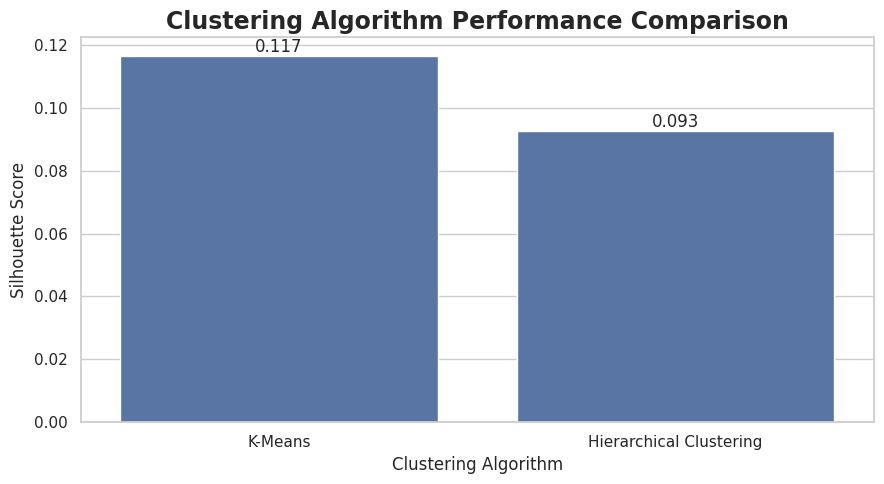

In [65]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=model_comparison,
    x='Algorithm',
    y='Silhouette Score'
)

plt.title(
    'Clustering Algorithm Performance Comparison',
    fontsize=17,
    fontweight='bold'
)

plt.xlabel('Clustering Algorithm')
plt.ylabel('Silhouette Score')

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.3f'
    )

plt.tight_layout()
plt.show()

## 🌳 Hierarchical Clustering Dendrogram

The dendrogram illustrates the hierarchical relationships among
buyers and provides a visual representation of how observations
are progressively grouped into clusters.

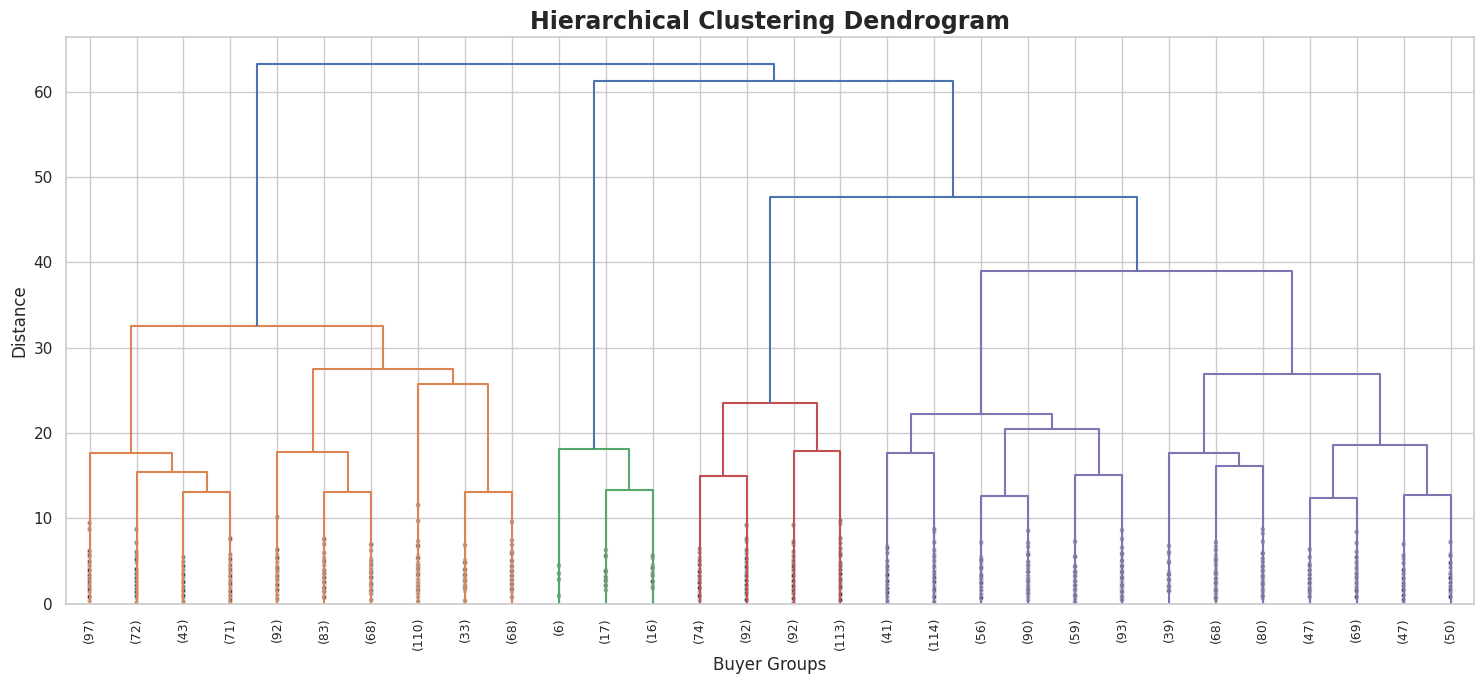

In [66]:
from scipy.cluster.hierarchy import linkage, dendrogram

# Create hierarchical linkage matrix
Z = linkage(
    X,
    method='ward'
)

plt.figure(figsize=(15, 7))

dendrogram(
    Z,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=9,
    show_contracted=True
)

plt.title(
    'Hierarchical Clustering Dendrogram',
    fontsize=17,
    fontweight='bold'
)

plt.xlabel('Buyer Groups')
plt.ylabel('Distance')

plt.tight_layout()
plt.show()

In [67]:
kmeans_distribution = (
    final_df['cluster']
    .value_counts()
    .sort_index()
)

hierarchical_distribution = (
    final_df['hierarchical_cluster']
    .value_counts()
    .sort_index()
)

cluster_distribution_comparison = pd.DataFrame({
    'K-Means': kmeans_distribution,
    'Hierarchical': hierarchical_distribution
})

display(
    cluster_distribution_comparison
)

,K-Means,Hierarchical
0,1297,1263
1,703,737


# 🏆 11. Final Buyer Segmentation

The K-Means segmentation is used as the primary buyer segmentation
framework because it provides clearly interpretable groups that can
be translated into actionable real estate customer profiles.

The segments are profiled using purchasing behavior, spending,
financing, acquisition purpose, demographics, and geography.

In [68]:
final_segment_profile = final_df.groupby('cluster').agg(
    Buyers=('client_id', 'count'),
    Avg_Age=('age', 'mean'),
    Avg_Satisfaction=('satisfaction_score', 'mean'),
    Avg_Properties=('properties_purchased', 'mean'),
    Avg_Total_Spend=('total_spend', 'mean'),
    Avg_Property_Price=('avg_property_price', 'mean'),
    Avg_Apartment_Purchases=('apartment_purchases', 'mean'),
    Avg_Office_Purchases=('office_purchases', 'mean')
).round(2)

display(final_segment_profile)

,Buyers,Avg_Age,Avg_Satisfaction,Avg_Properties,Avg_Total_Spend,Avg_Property_Price,Avg_Apartment_Purchases,Avg_Office_Purchases
cluster,,,,,,,,
0,1297,55.56,2.96,3.29,1121831.07,343714.91,2.60,0.69
1,703,57.38,3.16,4.32,1515983.03,353316.76,4.06,0.26


In [69]:
investment_percentage = (
    pd.crosstab(
        final_df['cluster'],
        final_df['acquisition_purpose'],
        normalize='index'
    ) * 100
)

investment_percentage = investment_percentage.round(2)

display(investment_percentage)

acquisition_purpose,Home,Investment
cluster,,
0,67.85,32.15
1,71.83,28.17


In [70]:
loan_percentage = (
    pd.crosstab(
        final_df['cluster'],
        final_df['loan_applied'],
        normalize='index'
    ) * 100
).round(2)

display(loan_percentage)

loan_applied,No,Yes
cluster,,
0,62.14,37.86
1,65.15,34.85


In [71]:
company_percentage = (
    pd.crosstab(
        final_df['cluster'],
        final_df['client_type'],
        normalize='index'
    ) * 100
).round(2)

display(company_percentage)

client_type,Company,Individual
cluster,,
0,4.86,95.14
1,5.69,94.31


In [72]:
business_profile = final_df.groupby('cluster').agg(
    Buyers=('client_id', 'count'),
    Avg_Age=('age', 'mean'),
    Avg_Satisfaction=('satisfaction_score', 'mean'),
    Avg_Properties=('properties_purchased', 'mean'),
    Avg_Spend=('total_spend', 'mean'),
    Avg_Property_Price=('avg_property_price', 'mean')
).round(2)

# Add investment percentage
investment_pct = (
    final_df
    .assign(
        is_investment=
        final_df['acquisition_purpose'].eq('Investment')
    )
    .groupby('cluster')['is_investment']
    .mean()
    * 100
)

business_profile['Investment %'] = investment_pct.round(2)

# Add loan percentage
loan_pct = (
    final_df
    .assign(
        uses_loan=
        final_df['loan_applied'].eq('Yes')
    )
    .groupby('cluster')['uses_loan']
    .mean()
    * 100
)

business_profile['Loan %'] = loan_pct.round(2)

# Add company percentage
company_pct = (
    final_df
    .assign(
        is_company=
        final_df['client_type'].eq('Company')
    )
    .groupby('cluster')['is_company']
    .mean()
    * 100
)

business_profile['Company %'] = company_pct.round(2)

display(business_profile)

,Buyers,Avg_Age,Avg_Satisfaction,Avg_Properties,Avg_Spend,Avg_Property_Price,Investment %,Loan %,Company %
cluster,,,,,,,,,
0,1297,55.56,2.96,3.29,1121831.07,343714.91,32.15,37.86,4.86
1,703,57.38,3.16,4.32,1515983.03,353316.76,28.17,34.85,5.69


In [73]:
print("Highest Investment-Oriented Cluster:")
print(
    business_profile['Investment %'].idxmax()
)

print("\nHighest Spending Cluster:")
print(
    business_profile['Avg_Spend'].idxmax()
)

print("\nHighest Company-Dominated Cluster:")
print(
    business_profile['Company %'].idxmax()
)

print("\nHighest Loan-Dependent Cluster:")
print(
    business_profile['Loan %'].idxmax()
)

print("\nHighest Property-Purchase Cluster:")
print(
    business_profile['Avg_Properties'].idxmax()
)

Highest Investment-Oriented Cluster:
0

Highest Spending Cluster:
1

Highest Company-Dominated Cluster:
1

Highest Loan-Dependent Cluster:
0

Highest Property-Purchase Cluster:
1


In [74]:
# ============================================================
# DETAILED BUYER SEGMENT CHARACTERISTICS
# ============================================================

for cluster in sorted(final_df['cluster'].unique()):

    data = final_df[final_df['cluster'] == cluster]

    investment_pct = (
        (data['acquisition_purpose'] == 'Investment').mean() * 100
    )

    loan_pct = (
        (data['loan_applied'] == 'Yes').mean() * 100
    )

    company_pct = (
        (data['client_type'] == 'Company').mean() * 100
    )

    print("\n" + "="*65)
    print(f"CLUSTER {cluster}")
    print("="*65)

    print(f"Buyers: {len(data)}")
    print(f"Average Age: {data['age'].mean():.2f}")
    print(f"Average Satisfaction: {data['satisfaction_score'].mean():.2f}")
    print(f"Average Properties: {data['properties_purchased'].mean():.2f}")
    print(f"Average Total Spend: {data['total_spend'].mean():.2f}")
    print(f"Average Property Price: {data['avg_property_price'].mean():.2f}")

    print(f"Investment Buyers: {investment_pct:.2f}%")
    print(f"Loan Users: {loan_pct:.2f}%")
    print(f"Company Buyers: {company_pct:.2f}%")

    print("\nTop Acquisition Purpose:")
    print(data['acquisition_purpose'].value_counts().head())

    print("\nTop Client Type:")
    print(data['client_type'].value_counts().head())

    print("\nTop Countries:")
    print(data['country'].value_counts().head(3))


CLUSTER 0
Buyers: 1297
Average Age: 55.56
Average Satisfaction: 2.96
Average Properties: 3.29
Average Total Spend: 1121831.07
Average Property Price: 343714.91
Investment Buyers: 32.15%
Loan Users: 37.86%
Company Buyers: 4.86%

Top Acquisition Purpose:
acquisition_purpose
Home          880
Investment    417
Name: count, dtype: int64

Top Client Type:
client_type
Individual    1234
Company         63
Name: count, dtype: int64

Top Countries:
country
USA       984
Canada     61
UK         59
Name: count, dtype: int64

CLUSTER 1
Buyers: 703
Average Age: 57.38
Average Satisfaction: 3.16
Average Properties: 4.32
Average Total Spend: 1515983.03
Average Property Price: 353316.76
Investment Buyers: 28.17%
Loan Users: 34.85%
Company Buyers: 5.69%

Top Acquisition Purpose:
acquisition_purpose
Home          505
Investment    198
Name: count, dtype: int64

Top Client Type:
client_type
Individual    663
Company        40
Name: count, dtype: int64

Top Countries:
country
USA       554
UK         36

In [75]:
cluster_2 = final_df[
    final_df['cluster'] == 2
]

print("CLUSTER 2 PROFILE")
print("="*60)

print("Number of Buyers:", len(cluster_2))

print(
    "\nAverage Age:",
    round(cluster_2['age'].mean(), 2)
)

print(
    "Average Satisfaction:",
    round(cluster_2['satisfaction_score'].mean(), 2)
)

print(
    "Average Properties:",
    round(cluster_2['properties_purchased'].mean(), 2)
)

print(
    "Average Total Spend:",
    round(cluster_2['total_spend'].mean(), 2)
)

print(
    "Average Property Price:",
    round(cluster_2['avg_property_price'].mean(), 2)
)

print(
    "\nInvestment %:",
    round(
        (cluster_2['acquisition_purpose'] == 'Investment').mean() * 100,
        2
    )
)

print(
    "Loan %:",
    round(
        (cluster_2['loan_applied'] == 'Yes').mean() * 100,
        2
    )
)

print(
    "Company %:",
    round(
        (cluster_2['client_type'] == 'Company').mean() * 100,
        2
    )
)

print("\nAcquisition Purpose:")
print(cluster_2['acquisition_purpose'].value_counts())

print("\nClient Type:")
print(cluster_2['client_type'].value_counts())

print("\nTop Countries:")
print(cluster_2['country'].value_counts().head(5))

CLUSTER 2 PROFILE
Number of Buyers: 0

Average Age: nan
Average Satisfaction: nan
Average Properties: nan
Average Total Spend: nan
Average Property Price: nan

Investment %: nan
Loan %: nan
Company %: nan

Acquisition Purpose:
Series([], Name: count, dtype: int64)

Client Type:
Series([], Name: count, dtype: int64)

Top Countries:
Series([], Name: count, dtype: int64)


In [76]:
segment_names = {
    0: "Financing-Driven Investors",
    1: "High-Value Corporate Buyers",
    2: "..."
}

final_df['segment_name'] = (
    final_df['cluster']
    .map(segment_names)
)

In [77]:
print("Optimal K:", OPTIMAL_K)

print("\nClusters actually present:")
print(sorted(final_df['cluster'].unique()))

print("\nNumber of buyers in each cluster:")
print(final_df['cluster'].value_counts().sort_index())

Optimal K: 2

Clusters actually present:
[np.int32(0), np.int32(1)]

Number of buyers in each cluster:
cluster
0    1297
1     703
Name: count, dtype: int64


In [78]:
for cluster in sorted(final_df['cluster'].unique()):

    data = final_df[final_df['cluster'] == cluster]

    investment_pct = (
        (data['acquisition_purpose'] == 'Investment').mean() * 100
    )

    loan_pct = (
        (data['loan_applied'] == 'Yes').mean() * 100
    )

    company_pct = (
        (data['client_type'] == 'Company').mean() * 100
    )

    print("\n" + "="*65)
    print(f"CLUSTER {cluster}")
    print("="*65)

    print(f"Number of Buyers: {len(data)}")
    print(f"Average Age: {data['age'].mean():.2f}")
    print(f"Average Satisfaction: {data['satisfaction_score'].mean():.2f}")
    print(f"Average Properties Purchased: {data['properties_purchased'].mean():.2f}")
    print(f"Average Total Spend: {data['total_spend'].mean():.2f}")
    print(f"Average Property Price: {data['avg_property_price'].mean():.2f}")
    print(f"Investment Buyers: {investment_pct:.2f}%")
    print(f"Loan Users: {loan_pct:.2f}%")
    print(f"Company Buyers: {company_pct:.2f}%")

    print("\nAcquisition Purpose:")
    print(data['acquisition_purpose'].value_counts())

    print("\nClient Type:")
    print(data['client_type'].value_counts())

    print("\nTop Countries:")
    print(data['country'].value_counts().head(5))


CLUSTER 0
Number of Buyers: 1297
Average Age: 55.56
Average Satisfaction: 2.96
Average Properties Purchased: 3.29
Average Total Spend: 1121831.07
Average Property Price: 343714.91
Investment Buyers: 32.15%
Loan Users: 37.86%
Company Buyers: 4.86%

Acquisition Purpose:
acquisition_purpose
Home          880
Investment    417
Name: count, dtype: int64

Client Type:
client_type
Individual    1234
Company         63
Name: count, dtype: int64

Top Countries:
country
USA        984
Canada      61
UK          59
Germany     42
France      37
Name: count, dtype: int64

CLUSTER 1
Number of Buyers: 703
Average Age: 57.38
Average Satisfaction: 3.16
Average Properties Purchased: 4.32
Average Total Spend: 1515983.03
Average Property Price: 353316.76
Investment Buyers: 28.17%
Loan Users: 34.85%
Company Buyers: 5.69%

Acquisition Purpose:
acquisition_purpose
Home          505
Investment    198
Name: count, dtype: int64

Client Type:
client_type
Individual    663
Company        40
Name: count, dtype: 

In [79]:
segment_names = {
    0: "Financing-Driven Investors",
    1: "High-Value Corporate Buyers"
}

final_df['segment_name'] = (
    final_df['cluster'].map(segment_names)
)

print(
    final_df[
        ['client_id', 'cluster', 'segment_name']
    ].head(10)
)

  client_id  cluster                 segment_name
0     C0001        1  High-Value Corporate Buyers
1     C0002        1  High-Value Corporate Buyers
2     C0003        1  High-Value Corporate Buyers
3     C0004        1  High-Value Corporate Buyers
4     C0005        1  High-Value Corporate Buyers
5     C0006        1  High-Value Corporate Buyers
6     C0007        1  High-Value Corporate Buyers
7     C0008        1  High-Value Corporate Buyers
8     C0009        1  High-Value Corporate Buyers
9     C0010        1  High-Value Corporate Buyers


In [80]:
final_segment_summary = final_df.groupby(
    ['cluster', 'segment_name']
).agg(
    Buyers=('client_id', 'count'),
    Avg_Age=('age', 'mean'),
    Avg_Satisfaction=('satisfaction_score', 'mean'),
    Avg_Properties=('properties_purchased', 'mean'),
    Avg_Total_Spend=('total_spend', 'mean'),
    Avg_Property_Price=('avg_property_price', 'mean')
).round(2)

display(final_segment_summary)

,,Buyers,Avg_Age,Avg_Satisfaction,Avg_Properties,Avg_Total_Spend,Avg_Property_Price
cluster,segment_name,,,,,,
0,Financing-Driven Investors,1297,55.56,2.96,3.29,1121831.07,343714.91
1,High-Value Corporate Buyers,703,57.38,3.16,4.32,1515983.03,353316.76


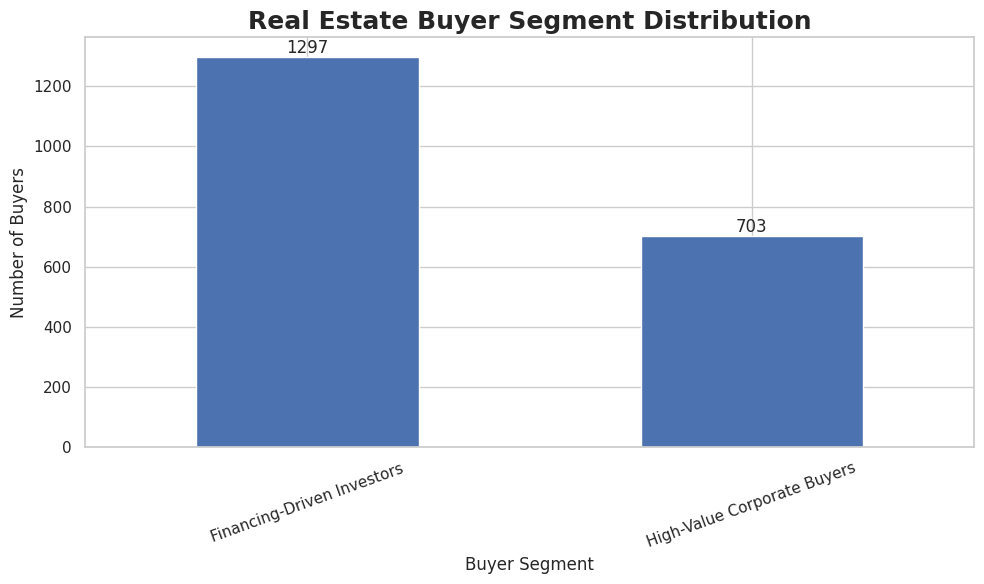

In [81]:
segment_counts = (
    final_df['segment_name']
    .value_counts()
)

plt.figure(figsize=(10, 6))

ax = segment_counts.plot(
    kind='bar'
)

plt.title(
    'Real Estate Buyer Segment Distribution',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Buyer Segment')
plt.ylabel('Number of Buyers')

plt.xticks(rotation=20)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [82]:
# Save the final segmented dataset

output_file = "real_estate_buyer_segments.csv"

final_df.to_csv(
    output_file,
    index=False
)

print("Dataset saved successfully:", output_file)
print("Rows:", len(final_df))
print("Columns:", len(final_df.columns))

Dataset saved successfully: real_estate_buyer_segments.csv
Rows: 2000
Columns: 23
